In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features

2026-02-25 09:49:58.165 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9_loader = QM9Dataset()
qm9_loader.load()

mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]

frames = qm9_loader.run_stress_test(mol_ids=mol_ids, max_rattle=2)
frames_rotated = qm9_loader.run_stress_test(mol_ids=mol_ids, rotated=True)

2026-02-25 09:49:59.996 | INFO     | src.datasets:load:62 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-25 09:50:00.106 | INFO     | src.geometry:generate_stress_test:56 - Generating Grassmann Stress Test (Seed=40, Rotated=False, Max Rattle=2)...
2026-02-25 09:50:00.156 | INFO     | src.geometry:generate_stress_test:123 - Generated 200 frames. Failed molecules: 0
2026-02-25 09:50:00.173 | SUCCESS  | src.geometry:generate_stress_test:127 - Saved stress test to data/QM9/stress_test.xyz
2026-02-25 09:50:00.173 | INFO     | src.geometry:generate_stress_test:56 - Generating Grassmann Stress Test (Seed=40, Rotated=True, Max Rattle=0.5)...
2026-02-25 09:50:00.196 | INFO     | src.geometry:generate_stress_test:123 - Generated 200 frames. Failed molecules: 0
2026-02-25 09:50:00.210 | SUCCESS  | src.geometry:generate_stress_test:127 - Saved stress test to data/QM9/stress_test_rotated.xyz


In [4]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 200 total frames.
[[ 3.98090537e+00  1.13826632e+00  1.76812295e+00]
 [ 1.90053441e-01  3.96083356e-01  2.16448490e+00]
 [ 5.81841722e-01 -7.81278981e-01  3.78223575e-01]
 [ 1.40916482e+00 -8.06098195e-01 -2.49949374e+00]
 [ 1.19977492e-01 -2.77182247e+00 -1.28940321e+00]
 [-2.47725970e+00 -1.77206608e+00  1.01771568e+00]
 [-9.95200802e-01 -5.12372151e-01 -1.34010878e+00]
 [ 2.37356916e+00  1.58467051e+00  2.58325517e-01]
 [ 3.49053159e+00 -2.43101819e-01  2.29998903e-03]
 [ 2.38316869e+00  5.52928835e-01 -1.98704348e+00]
 [-7.59625991e-01 -7.74427549e-01  8.33507477e-01]
 [-8.79183590e-01 -3.03935073e+00 -6.32987479e-01]
 [-2.85591453e+00 -1.75643558e+00 -3.24149210e-01]
 [-3.93431208e+00 -7.73090696e-01  4.29958057e-01]
 [-2.87485514e+00  6.79904055e-01  1.92497620e-01]
 [-4.03498367e+00 -6.73459651e-01  6.67784659e-01]
 [-1.68407723e+00 -4.21767430e-03 -2.67497004e+00]]
qm9_1478
[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]


In [5]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_1478:
Max displacement: 4.1415 Å
Min displacement: 0.1660 Å
Average displacement: 2.3839 Å (Target was ~0.2)


In [6]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 3.8831 Å
Standard Deviation of bond length: 1.1906 Å


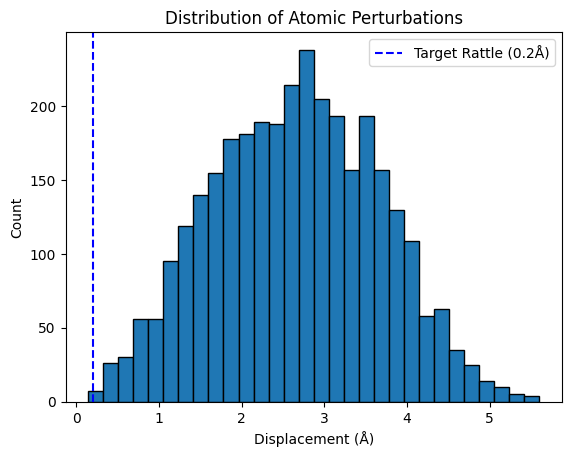

In [7]:
all_displacements = []

for m in range(0, 200, 20):
    ref_pos = frames[m].get_positions()
    for p in range(1, 20):
        pert_pos = frames[m + p].get_positions()
        diff = np.linalg.norm(pert_pos - ref_pos, axis=1)
        all_displacements.extend(diff)

plt.hist(all_displacements, bins=30, edgecolor='black')
plt.axvline(0.2, color='blue', linestyle='--', label='Target Rattle (0.2Å)')
plt.title("Distribution of Atomic Perturbations")
plt.xlabel("Displacement (Å)")
plt.ylabel("Count")
plt.legend()
plt.show()

# Clustering

In [8]:
import polars as pl

def make_clustering(frames, processed=False):
    # --- 1. Generate Features ---
    print("Generating geometric features...")
    if processed:
        X = get_features_xyz(frames)
    else:
        X = get_raw_xyz_features(frames)
        
    print(f"Feature matrix shape: {X.shape}")

    # --- 2. Clustering (K-Means) ---
    unique_mol_ids = list(set([f.info['mol_id'] for f in frames]))
    n_clusters = len(unique_mol_ids)

    print(f"Clustering into {n_clusters} clusters (based on unique mol_ids found)...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # --- 3. Evaluation ---
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info['smiles'] for f in frames]

    # Calculate Score
    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"Clustering Performance (Adjusted Rand Index): {ari_score:.4f}")

    # --- 4. Cluster Composition Table ---
    # We create a dataframe to easily group and see what went where
    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    # Summary: For each cluster, show which molecules it contains and how many
    # If ARI is 1.0, each cluster should only contain 1 unique mol_id
    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    print("\nCluster Composition Summary:")
    print(summary_table)

    # --- 5. Visualization (PCA) ---
    print("\nRunning PCA for visualization...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    expl_var = pca.explained_variance_ratio_

    # ---------- Styling for report quality ----------
    plt.style.use("seaborn-v0_8-whitegrid")  # clean academic style

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    # Choose color palette depending on number of clusters
    cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")

    # Scatter plot
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap=cmap,
        s=35,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.3
    )

    ax.set_xlabel("PCA Component 1", fontsize=12)
    ax.set_ylabel("PCA Component 2", fontsize=12)

    title_prefix = "Processed (Invariant)" if processed else "Flattened (Raw)"
    ax.set_title(
        f"{title_prefix} XYZ Features — Clustering of Perturbed Geometries\n"
        f"Adjusted Rand Index = {ari_score:.3f}",
        fontsize=14,
        pad=12
    )

    # Cleaner legend
    legend = ax.legend(
        *scatter.legend_elements(num=n_clusters),
        title="Cluster ID",
        loc="best",
        frameon=True
    )
    ax.add_artist(legend)

    # Improve layout
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    fig.tight_layout()

    # Save high quality figure for report
    plt.savefig(f"report/qm9/figures/grassmann/pca_clustering_{processed}.png", dpi=300, bbox_inches="tight")

    plt.show()
    
    return summary_table

Generating geometric features...
Feature matrix shape: (200, 136)
Clustering into 10 clusters (based on unique mol_ids found)...
Clustering Performance (Adjusted Rand Index): 0.0088

Cluster Composition Summary:
shape: (10, 5)
┌─────────┬─────────────┬─────────────────────────────┬────────────────────────────┬───────────────┐
│ cluster ┆ unique_mols ┆ mol_ids_in_cluster          ┆ representative_smiles      ┆ total_samples │
│ ---     ┆ ---         ┆ ---                         ┆ ---                        ┆ ---           │
│ i32     ┆ u32         ┆ list[str]                   ┆ str                        ┆ u32           │
╞═════════╪═════════════╪═════════════════════════════╪════════════════════════════╪═══════════════╡
│ 0       ┆ 9           ┆ ["qm9_1478", "qm9_1449", …  ┆ [H]C([H])([H])OC(=O)C([H]) ┆ 25            │
│         ┆             ┆ "qm…                        ┆ ([H]…                      ┆               │
│ 1       ┆ 7           ┆ ["qm9_1447", "qm9_1449", …  ┆ [H]C(=O)O[

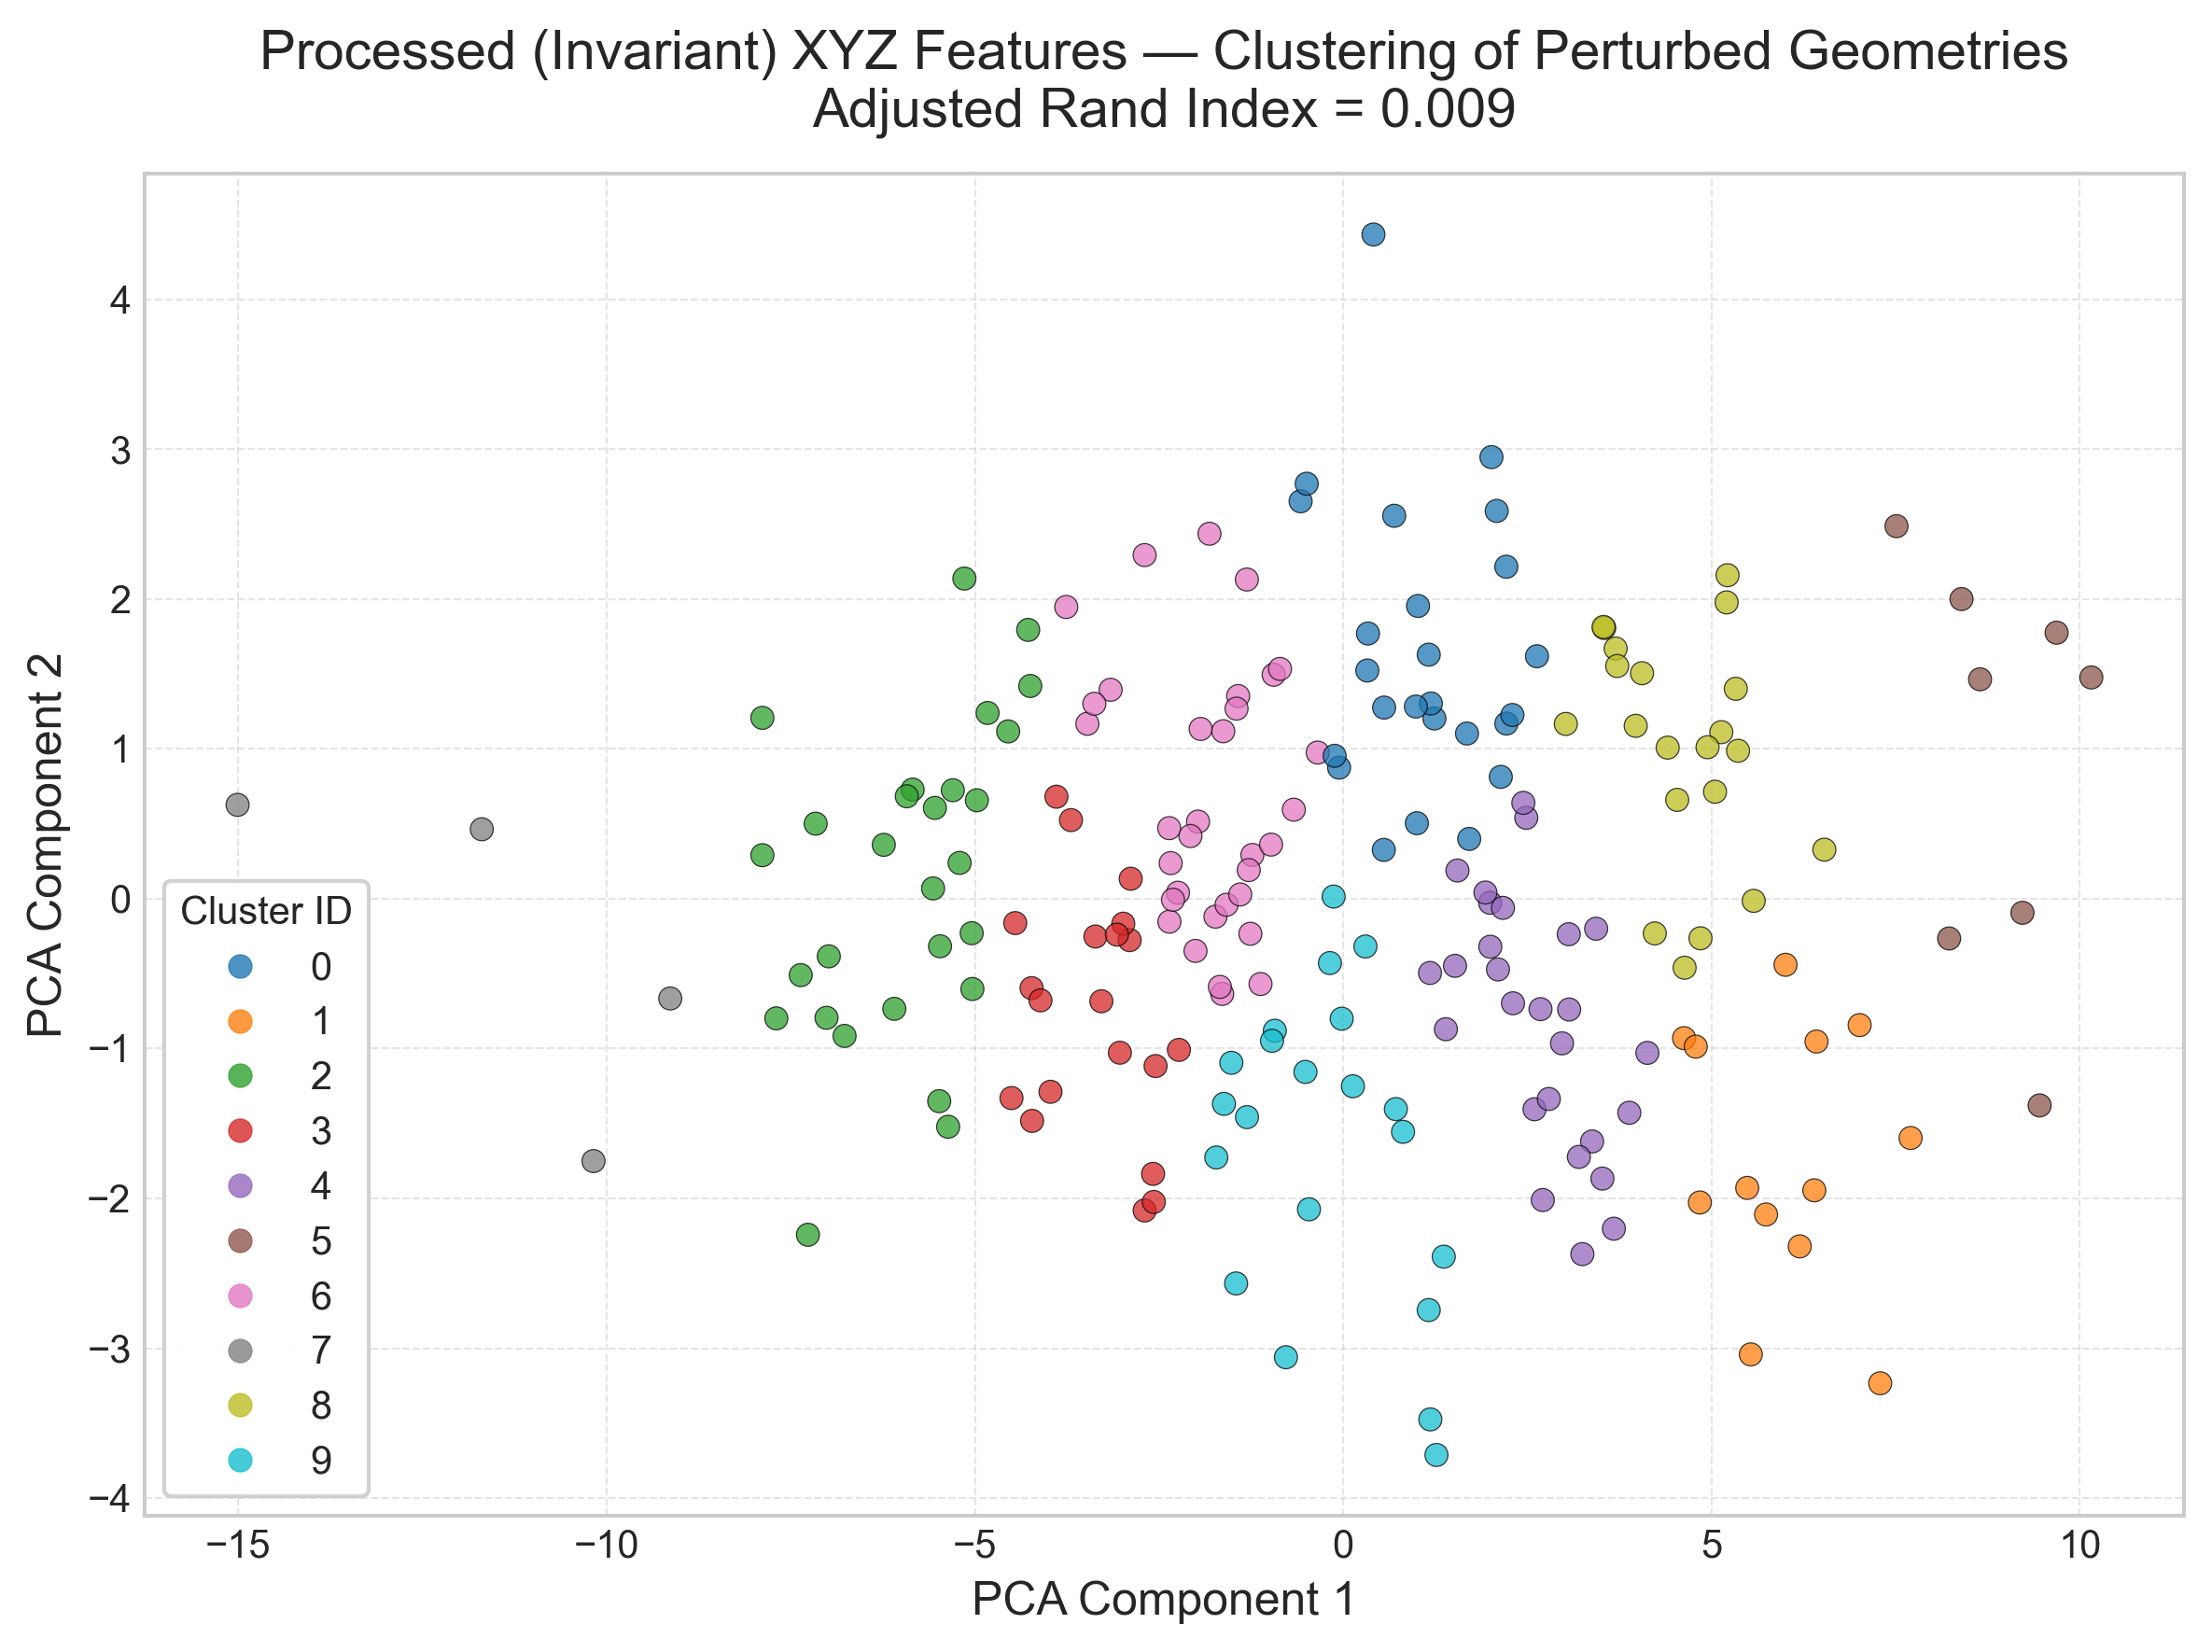

cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,9,"[""qm9_1478"", ""qm9_1449"", … ""qm9_1237""]","""[H]C([H])([H])OC(=O)C([H])([H]…",25
1,7,"[""qm9_1447"", ""qm9_1449"", … ""qm9_1237""]","""[H]C(=O)O[C@]([H])(C([H])([H])…",13
2,10,"[""qm9_1478"", ""qm9_1447"", … ""qm9_1237""]","""[H]C([H])([H])OC(=O)C([H])([H]…",28
3,10,"[""qm9_1478"", ""qm9_1447"", … ""qm9_1237""]","""[H]C([H])([H])OC(=O)C([H])([H]…",20
4,9,"[""qm9_1447"", ""qm9_1449"", … ""qm9_1237""]","""[H]C(=O)O[C@]([H])(C([H])([H])…",27
5,5,"[""qm9_1478"", ""qm9_1474"", … ""qm9_1237""]","""[H]C([H])([H])OC(=O)C([H])([H]…",8
6,10,"[""qm9_1478"", ""qm9_1447"", … ""qm9_1237""]","""[H]C([H])([H])OC(=O)C([H])([H]…",33
7,4,"[""qm9_1447"", ""qm9_1449"", … ""qm9_1476""]","""[H]C(=O)O[C@]([H])(C([H])([H])…",4
8,7,"[""qm9_1478"", ""qm9_1474"", … ""qm9_1237""]","""[H]C([H])([H])OC(=O)C([H])([H]…",21


In [9]:
make_clustering(frames, processed=True)

Generating geometric features...
flat list 1: [ 3.98090537e+00  1.13826632e+00  1.76812295e+00  1.90053441e-01
  3.96083356e-01  2.16448490e+00  5.81841722e-01 -7.81278981e-01
  3.78223575e-01  1.40916482e+00 -8.06098195e-01 -2.49949374e+00
  1.19977492e-01 -2.77182247e+00 -1.28940321e+00 -2.47725970e+00
 -1.77206608e+00  1.01771568e+00 -9.95200802e-01 -5.12372151e-01
 -1.34010878e+00  2.37356916e+00  1.58467051e+00  2.58325517e-01
  3.49053159e+00 -2.43101819e-01  2.29998903e-03  2.38316869e+00
  5.52928835e-01 -1.98704348e+00 -7.59625991e-01 -7.74427549e-01
  8.33507477e-01 -8.79183590e-01 -3.03935073e+00 -6.32987479e-01
 -2.85591453e+00 -1.75643558e+00 -3.24149210e-01 -3.93431208e+00
 -7.73090696e-01  4.29958057e-01 -2.87485514e+00  6.79904055e-01
  1.92497620e-01 -4.03498367e+00 -6.73459651e-01  6.67784659e-01
 -1.68407723e+00 -4.21767430e-03 -2.67497004e+00]
flat list 2: [ 2.9825364  -0.08011464 -1.46036309  0.35844756  1.55958209  1.67746344
  1.1280433  -0.43229673  1.70620444  

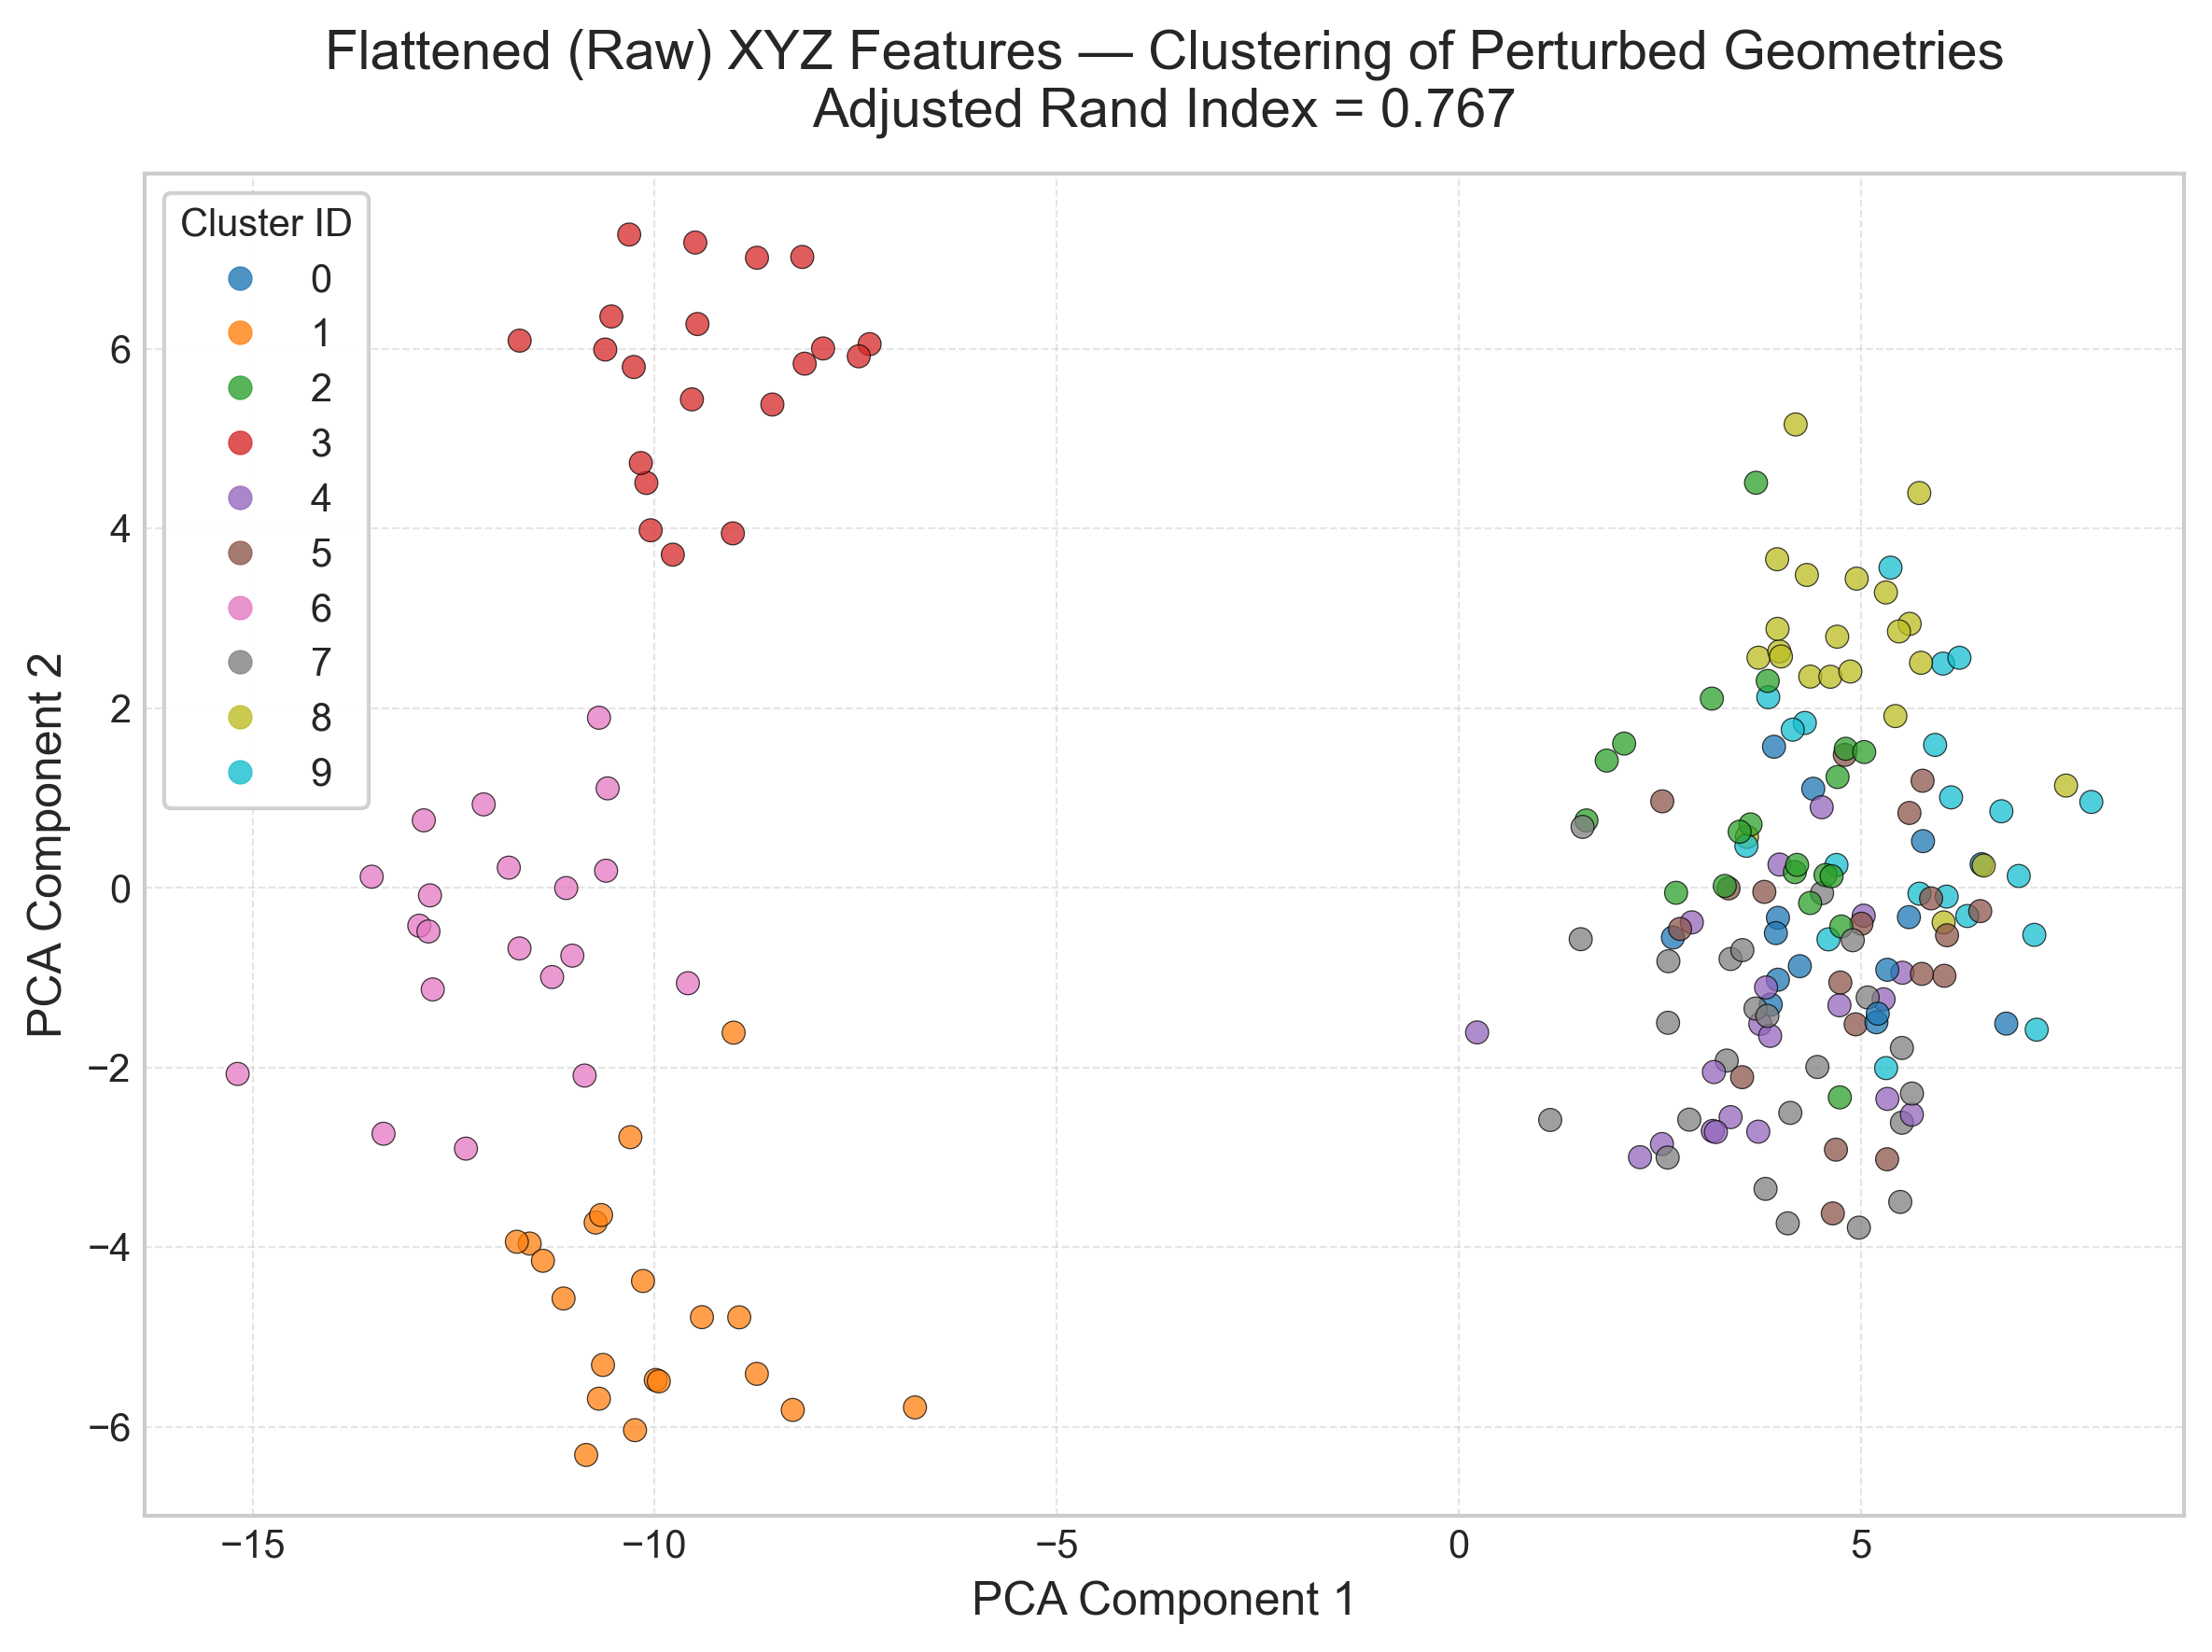

cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,3,"[""qm9_1478"", ""qm9_1244"", ""qm9_1476""]","""[H]C([H])([H])OC(=O)C([H])([H]…",15
1,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])…",20
2,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H…",20
3,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(…",20
4,4,"[""qm9_1478"", ""qm9_1244"", … ""qm9_1476""]","""[H]C([H])([H])OC(=O)C([H])([H]…",20
5,2,"[""qm9_1246"", ""qm9_1476""]","""[H]C([H])([H])C(=O)C([H])([H])…",19
6,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H…",20
7,3,"[""qm9_1478"", ""qm9_1244"", ""qm9_1476""]","""[H]C([H])([H])OC(=O)C([H])([H]…",24
8,4,"[""qm9_1474"", ""qm9_1486"", … ""qm9_1476""]","""[H]C([H])([H])OC([H])([H])C(=O…",22


In [10]:
make_clustering(frames, processed=False)

In [11]:
frames[0].info['mol_id']

'qm9_1478'


 ADJUSTED RAND INDEX (ARI): 0.1994

--- Cluster Assignments & Unique Mol IDs ---
Cluster 0:
  Total frames: 21
  Unique molecules: 4
  Mol IDs: ['qm9_1447', 'qm9_1476', 'qm9_1248', 'qm9_1237']

Cluster 1:
  Total frames: 75
  Unique molecules: 9
  Mol IDs: ['qm9_1237', 'qm9_1248', 'qm9_1476', 'qm9_1478', 'qm9_1474', 'qm9_1447', 'qm9_1246', 'qm9_1486', 'qm9_1244']

Cluster 2:
  Total frames: 6
  Unique molecules: 2
  Mol IDs: ['qm9_1486', 'qm9_1474']

Cluster 3:
  Total frames: 37
  Unique molecules: 7
  Mol IDs: ['qm9_1237', 'qm9_1248', 'qm9_1476', 'qm9_1478', 'qm9_1447', 'qm9_1246', 'qm9_1486']

Cluster 4:
  Total frames: 26
  Unique molecules: 5
  Mol IDs: ['qm9_1476', 'qm9_1248', 'qm9_1478', 'qm9_1449', 'qm9_1447']

Cluster 5:
  Total frames: 1
  Unique molecules: 1
  Mol IDs: ['qm9_1474']

Cluster 6:
  Total frames: 7
  Unique molecules: 1
  Mol IDs: ['qm9_1246']

Cluster 7:
  Total frames: 2
  Unique molecules: 2
  Mol IDs: ['qm9_1246', 'qm9_1244']

Cluster 8:
  Total frames: 6
 

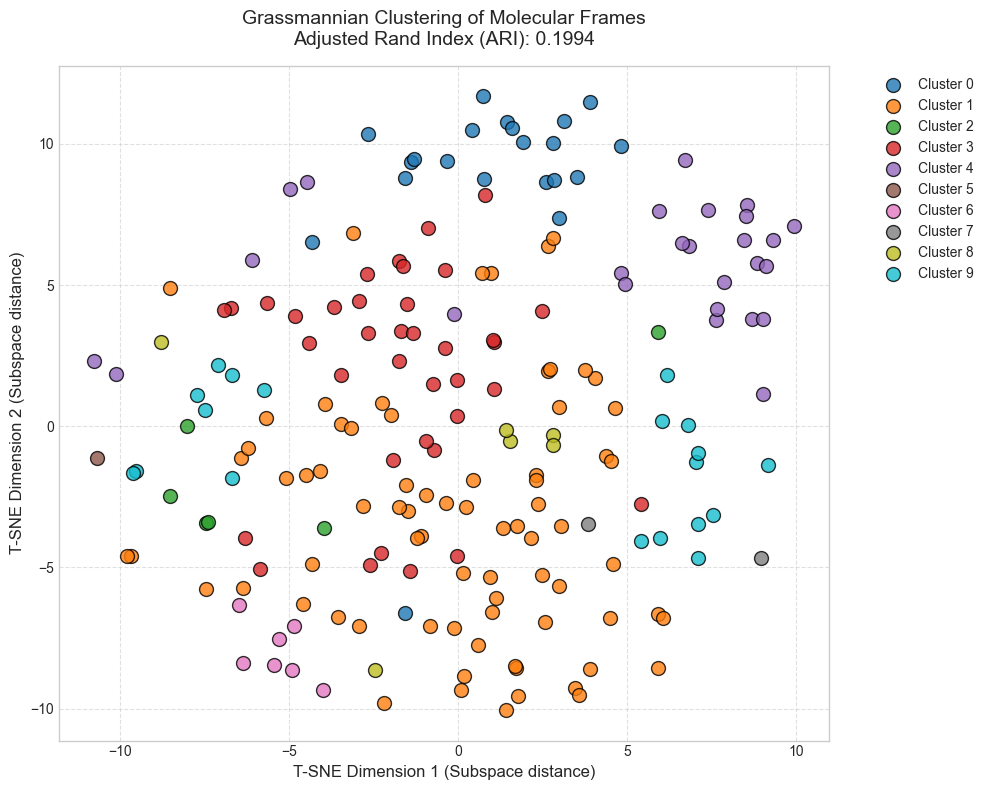

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS, TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score  # <-- NEW IMPORT
from src.features import Grassmann

# Compute distances directly from frames
dist_matrix = Grassmann.distance_matrix(frames)

# 4. Cluster! 
n_clusters = 10
clustering = AgglomerativeClustering(
    n_clusters=n_clusters, 
    metric='precomputed', 
    linkage='average'
)
labels = clustering.fit_predict(dist_matrix)

# ---------------------------------------------------------
# NEW: COMPUTE ADJUSTED RAND INDEX (ARI)
# ---------------------------------------------------------
# Extract the ground truth labels (the actual mol_ids)
true_labels = [frame.info['mol_id'] for frame in frames]

# Calculate ARI (1.0 is perfect match, 0.0 is random assignment)
ari_score = adjusted_rand_score(true_labels, labels)
print(f"\n============================================")
print(f" ADJUSTED RAND INDEX (ARI): {ari_score:.4f}")
print(f"============================================\n")


print("--- Cluster Assignments & Unique Mol IDs ---")
for cluster_id in range(n_clusters):
    # Get the indices (frame numbers) that belong to this cluster
    frame_indices = np.where(labels == cluster_id)[0]
    
    # Extract the mol_id for each frame in this cluster
    mol_ids_in_cluster = [frames[i].info['mol_id'] for i in frame_indices]
    
    # Use a set to get only the unique mol_ids
    unique_mol_ids = set(mol_ids_in_cluster)
    
    print(f"Cluster {cluster_id}:")
    print(f"  Total frames: {len(frame_indices)}")
    print(f"  Unique molecules: {len(unique_mol_ids)}")
    print(f"  Mol IDs: {list(unique_mol_ids)}\n")
print("--------------------------------------------\n")

tsne = TSNE(
    n_components=2,
    metric='precomputed',
    init='random',
    random_state=42,
    perplexity=30, 
    #n_iter=1000
)

coords_2d = tsne.fit_transform(dist_matrix)

# 6. Plot the clusters
plt.figure(figsize=(10, 8))

# Use the 'tab10' colormap which is perfect for up to 10 distinct categories
cmap = plt.get_cmap('tab10')

for label in np.unique(labels):
    idx = labels == label
    plt.scatter(
        coords_2d[idx, 0], 
        coords_2d[idx, 1], 
        s=100, 
        color=cmap(label), 
        label=f'Cluster {label}', 
        edgecolors='black', 
        alpha=0.8
    )

# Updated Title to include the ARI score dynamically
plt.title(f'Grassmannian Clustering of Molecular Frames\nAdjusted Rand Index (ARI): {ari_score:.4f}', fontsize=14, pad=15)
plt.xlabel('T-SNE Dimension 1 (Subspace distance)', fontsize=12)
plt.ylabel('T-SNE Dimension 2 (Subspace distance)', fontsize=12)

# Place the legend outside the plot so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()